# Multi-config halo-mass posterior sweeps

This notebook is a compact follow-up to `run_simulations.ipynb`.
It builds the analogue catalogue once, then reruns the posterior inference for several feature configurations such as separation only, separation plus velocities, and separation plus velocities plus stellar masses.

Use the settings cell below to choose:
- `PAIR_SUBSET`: `"blue_blue"`, `"red_red"`, `"blue_or_red"`, or `"all"`
- `INFERENCE_METHOD`: `"abc"`, `"gmm"`, or `"sbi"`

The active target is still read from `config/config.json`, and this notebook expects that target to be `total_virial_mass`.


In [64]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

cwd = Path.cwd().resolve()
repo_root = next((path for path in [cwd, *cwd.parents] if (path / "analogues").is_dir()), None)
if repo_root is None:
    raise FileNotFoundError("Could not find the repo root containing the `analogues` package.")

for pth in [repo_root, repo_root / "scripts", repo_root / "illustris_python"]:
    if pth.exists() and str(pth) not in sys.path:
        sys.path.insert(0, str(pth))

from config.loader import load_config
from lg_multi_config_posteriors import (
    DEFAULT_SBI_CONFIG,
    build_analogue_sample,
    build_pair_catalog,
    pair_subset_display_name,
    plot_configuration_posteriors,
    run_configuration_grid,
)

print("Repo root:", repo_root)


Repo root: /home/tp/Documents/uni/dsp


## Settings

You do not need to toggle feature `active` flags in `config/config.json` for this notebook.
The config file is used for the observed values, sigmas, selection/filter settings, and target metadata, while the feature subsets are defined explicitly below.


In [65]:
config_loader = load_config()
analysis_config = config_loader.get_config()

if analysis_config.target_name != "total_virial_mass":
    raise ValueError(
        "This notebook expects `total_virial_mass` to be the active target in config/config.json. "
        f"Found: {analysis_config.target_name!r}"
    )

FEATURE_INFO = analysis_config.all_features
LOG10_FEATURES = {
    name for name, meta in FEATURE_INFO.items()
    if bool(meta.get("log10", False))
}

TARGET_COLUMN = analysis_config.target["column"]
TARGET_LABEL = analysis_config.target.get("label", TARGET_COLUMN)
TARGET_LOG10 = bool(analysis_config.target.get("log10", False))

PAIR_SUBSET = "blue_or_red" #  `"blue_blue"`, `"red_red"`, `"blue_or_red"`, or `"all"`
INFERENCE_METHOD = "abc"  # choose from: "abc", "gmm", "sbi"
SNAP = 99

FEATURE_CONFIGS = [
    {"label": "Separation only", "features": ["r_kpc"]},
    {"label": r"$v_r$ + sep", "features": ["r_kpc", "v_r"]},
    {"label": r"$v_r$ + $v_t$ + sep", "features": ["r_kpc", "v_r", "v_t"]},
    {
        "label": r"$v_r$ + $v_t$ + sep + $M_*$",
        "features": ["r_kpc", "v_r", "v_t", "mstar_big", "mstar_small"],
    },
]

ABC_ACCEPT_FRAC = 0.05
ABC_KERNEL_BANDWIDTH = 1.0

GMM_COMPONENTS = "bic"
GMM_RANDOM_STATE = 42

NUM_POSTERIOR_SAMPLES = 20_000
RANDOM_STATE = 42
SBI_CONFIG = dict(DEFAULT_SBI_CONFIG)

REFERENCE_LOG_MASS = 12.6
REFERENCE_LABEL = "Real LG estimate ~12.6 (van der Marel 2012)"
PLOT_XLABEL = r"log total virial mass [$M_{\odot}$]"

feature_rows = []
for model_config in FEATURE_CONFIGS:
    for feature_name in model_config["features"]:
        meta = FEATURE_INFO[feature_name]
        feature_rows.append(
            {
                "model": model_config["label"],
                "feature": feature_name,
                "observed_value": meta["obs"],
                "sigma": meta["sigma"],
                "label": meta.get("label", feature_name),
                "description": meta.get("description", ""),
            }
        )

display(pd.DataFrame(feature_rows))
display(config_loader.show_active_target())
print("Pair subset:", pair_subset_display_name(PAIR_SUBSET))
print("Inference method:", INFERENCE_METHOD)


,model,feature,observed_value,sigma,label,description
0,Separation only,r_kpc,7.650000e+02,1.100000e+01,Pair separation $r$ [kpc],Current MW-M31 separation proxy.
1,$v_r$ + sep,r_kpc,7.650000e+02,1.100000e+01,Pair separation $r$ [kpc],Current MW-M31 separation proxy.
2,$v_r$ + sep,v_r,-1.093000e+02,4.400000e+00,Radial velocity $v_r$ [km/s],Relative radial velocity of the pair.
3,$v_r$ + $v_t$ + sep,r_kpc,7.650000e+02,1.100000e+01,Pair separation $r$ [kpc],Current MW-M31 separation proxy.
4,$v_r$ + $v_t$ + sep,v_r,-1.093000e+02,4.400000e+00,Radial velocity $v_r$ [km/s],Relative radial velocity of the pair.
5,$v_r$ + $v_t$ + sep,v_t,5.700000e+01,3.500000e+01,Tangential velocity $v_t$ [km/s],Relative tangential velocity of the pair.
6,$v_r$ + $v_t$ + sep + $M_*$,r_kpc,7.650000e+02,1.100000e+01,Pair separation $r$ [kpc],Current MW-M31 separation proxy.
7,$v_r$ + $v_t$ + sep + $M_*$,v_r,-1.093000e+02,4.400000e+00,Radial velocity $v_r$ [km/s],Relative radial velocity of the pair.
8,$v_r$ + $v_t$ + sep + $M_*$,v_t,5.700000e+01,3.500000e+01,Tangential velocity $v_t$ [km/s],Relative tangential velocity of the pair.
9,$v_r$ + $v_t$ + sep + $M_*$,mstar_big,5.000000e+10,1.000000e+10,Larger stellar mass,Stellar mass of the more massive member.


,column,log10,active,label,description
total_virial_mass,log_tot_virial_mass,False,True,Log Total virial mass,"Total virial mass of the pair,"


Pair subset: Blue-Blue + Red-Red
Inference method: abc


## Build the analogue catalogue once

This follows the same selection and filtering logic as `run_simulations.ipynb`, but the pair subset is applied only once and then reused by every feature configuration.


In [66]:
analogue_sample = build_analogue_sample(
    repo_root,
    selection_config=analysis_config.selection,
    filter_config=analysis_config.filter,
    snap=SNAP,
    verbose=True,
)

display(pd.DataFrame(analogue_sample._pipeline.get_cutflow()))

catalog, color_summary = build_pair_catalog(
    analogue_sample,
    pair_subset=PAIR_SUBSET,
)

display(color_summary)



[DIAGNOSTIC] Simulation Header Constants
╒════════════╤═══════════╤═══════════════╕
│ Parameter  │ Value     │ Units         │
├────────────┼───────────┼───────────────┤
│ Hubble (h) │ 0.6774    │ dimensionless │
├────────────┼───────────┼───────────────┤
│ Box Side   │ 302627.69 │ kpc           │
╘════════════╧═══════════╧═══════════════╛

[DIAGNOSTIC] Sample Selection
╒═════════════════════════════════════════╤══════════╤═════════════════╕
│ Selection Step                          │    Count │ Yield           │
╞═════════════════════════════════════════╪══════════╪═════════════════╡
│ Total Subhalos in Catalog               │ 14485709 │ 100.0%          │
├─────────────────────────────────────────┼──────────┼─────────────────┤
│ Passed Quality Flags (SubhaloFlag==1)   │  1902558 │ 13.1%           │
├─────────────────────────────────────────┼──────────┼─────────────────┤
│ Inside Stellar Mass Window              │    60562 │ 3.2% of good    │
├─────────────────────────────────────────

,label,before,after,frac_kept
0,initial,2655,2655,1.000000
1,No third subhalo more massive than factor x=1....,2655,2601,0.979661
2,No subhalos more massive than factor x=0.5 wit...,2601,2600,0.999616
3,"vt in [0, 300], vr in [-400, 0], v_tot in [0, ...",2600,1761,0.677308


,pair_subset,total_pairs_before_subset,blue_blue,red_red,mixed_blue_red,pairs_after_subset
0,Blue-Blue + Red-Red,1761,198,827,736,1025


## Run the feature sweep

Each row below corresponds to one posterior curve in the final figure.


In [67]:
results, summary_df = run_configuration_grid(
    catalog=catalog,
    feature_info=FEATURE_INFO,
    configurations=FEATURE_CONFIGS,
    target_column=TARGET_COLUMN,
    target_label=TARGET_LABEL,
    method=INFERENCE_METHOD,
    log10_features=LOG10_FEATURES,
    target_log10=TARGET_LOG10,
    abc_accept_frac=ABC_ACCEPT_FRAC,
    abc_kernel_bandwidth=ABC_KERNEL_BANDWIDTH,
    gmm_components=GMM_COMPONENTS,
    gmm_random_state=GMM_RANDOM_STATE,
    sbi_config=SBI_CONFIG,
    num_samples=NUM_POSTERIOR_SAMPLES,
    random_state=RANDOM_STATE,
)

display(summary_df)


,label,method,features,n_features,n_pairs_used,dropped_nonfinite,support_n_outside,support_nearest_distance,mean,median,q16,q84,ess
0,Separation only,abc,r_kpc,1,1025,0,0,0.018760,12.874365,12.802671,12.593096,13.175914,68.854216
1,$v_r$ + sep,abc,"r_kpc, v_r",2,1025,0,0,0.243584,12.652170,12.664551,12.527324,12.760572,5.188477
2,$v_r$ + $v_t$ + sep,abc,"r_kpc, v_r, v_t",3,1025,0,0,1.030927,12.646130,12.664707,12.527287,12.760356,2.916136
3,$v_r$ + $v_t$ + sep + $M_*$,abc,"r_kpc, v_r, v_t, mstar_big, mstar_small",5,1025,0,0,2.016733,12.686897,12.760383,12.630906,12.760660,2.735293


## Plot the posteriors

The dashed vertical line is optional and is included here to match the comparison style in your example figure.


(11.0, 15.0)

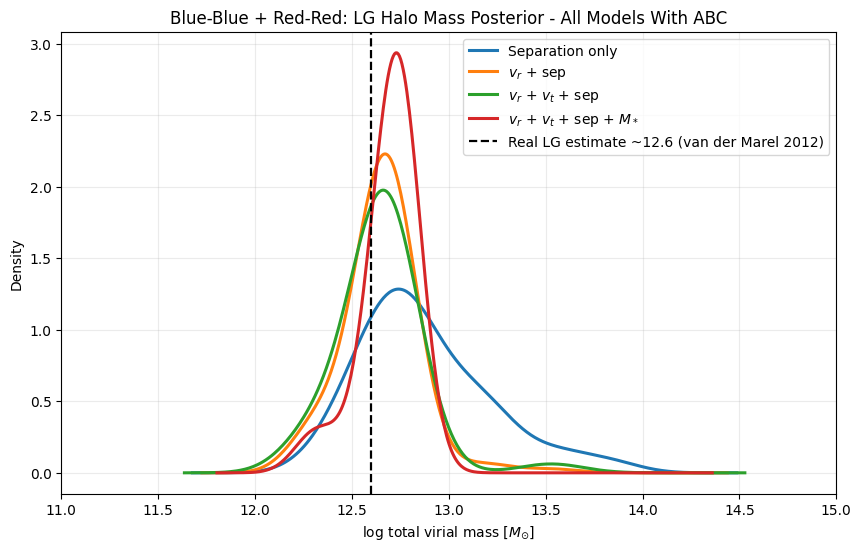

In [68]:
title = f"{pair_subset_display_name(PAIR_SUBSET)}: LG Halo Mass Posterior - All Models With {INFERENCE_METHOD.upper()}"

fig, ax = plot_configuration_posteriors(
    results,
    title=title,
    x_label=PLOT_XLABEL,
    reference_value=REFERENCE_LOG_MASS,
    reference_label=REFERENCE_LABEL,
    figsize=(10, 6),
)
ax.set_xlim(11.0, 15.0)

